In [59]:
import geopandas as gpd

linkGit='https://github.com/andreadiaz2024/exame1_Andrea/raw/refs/heads/main/'
linkWorldMaps='Data/worldMaps.gpkg'

gpd.list_layers(linkGit+linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


In [60]:
countries=gpd.read_file(linkGit+linkWorldMaps,layer='countries')

countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


In [62]:
import pandas as pd

someDataLink='Data/some_dataworld.csv'
someData=pd.read_csv(linkGit+someDataLink)

someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


In [63]:
countries.COUNTRY.head()


,COUNTRY
0,Aruba (Netherlands)
1,Antigua and Barbuda
2,Afghanistan
3,Algeria
4,Azerbaijan


In [64]:
someData.Country.head()

,Country
0,AFGHANISTAN
1,ALBANIA
2,ALGERIA
3,ANGOLA
4,ANTIGUA AND BARBUDA


In [65]:

countries.rename(columns={'COUNTRY':'Country'},inplace=True)
countries['Country']=countries.Country.str.upper()

onlyDF=set(someData.Country)- set(countries.Country)
onlyGDF=set(countries.Country)- set(someData.Country)



In [67]:
!pip install thefuzz
from thefuzz.process import extractOne as best



In [68]:
pd.DataFrame([(country, best(country,onlyGDF)[0],best(country,onlyGDF)[1]) for country in onlyDF]).sort_values(by=2)

,0,1,2
16,CÔTE D'IVOIRE,IVORY COAST,58
8,ESWATINI,LIECHTENSTEIN,60
21,CABO VERDE,CAPE VERDE,80
17,TIMOR-LESTE,EAST TIMOR,81
18,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),CZECH REPUBLIC,86
26,KOREA (THE REPUBLIC OF),CZECH REPUBLIC,86
3,BRUNEI DARUSSALAM,BRUNEI,90
0,RUSSIAN FEDERATION (THE),RUSSIA,90
14,SAMOA,WESTERN SAMOA,90
13,MOLDOVA (THE REPUBLIC OF),MOLDOVA,90


In [69]:
changesToDF={country: best(country,onlyGDF)[0] for country in onlyDF}
changesToDF

{'RUSSIAN FEDERATION (THE)': 'RUSSIA',
 'CENTRAL AFRICAN REPUBLIC (THE)': 'CENTRAL AFRICAN REPUBLIC',
 'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND (THE)': 'UNITED KINGDOM',
 'BRUNEI DARUSSALAM': 'BRUNEI',
 'PHILIPPINES (THE)': 'PHILIPPINES',
 'NORTHERN MARIANA ISLANDS (THE)': 'NORTHERN MARIANA ISLANDS (US)',
 'BAHAMAS (THE)': 'BAHAMAS',
 'NETHERLANDS (THE)': 'NETHERLANDS',
 'ESWATINI': 'LIECHTENSTEIN',
 'COMOROS (THE)': 'COMOROS',
 'UNITED ARAB EMIRATES (THE)': 'UNITED ARAB EMIRATES',
 'GAMBIA (THE)': 'GAMBIA',
 'NORTH MACEDONIA': 'MACEDONIA',
 'MOLDOVA (THE REPUBLIC OF)': 'MOLDOVA',
 'SAMOA': 'WESTERN SAMOA',
 'DOMINICAN REPUBLIC (THE)': 'DOMINICAN REPUBLIC',
 "CÔTE D'IVOIRE": 'IVORY COAST',
 'TIMOR-LESTE': 'EAST TIMOR',
 "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)": 'CZECH REPUBLIC',
 'BOLIVIA (PLURINATIONAL STATE OF)': 'BOLIVIA',
 'CONGO (THE)': 'CONGO',
 'CABO VERDE': 'CAPE VERDE',
 'TANZANIA, THE UNITED REPUBLIC OF': 'TANZANIA',
 'MICRONESIA (FEDERATED STATES OF)': 'FEDERATE

In [70]:
someData.replace(to_replace={'Country':changesToDF},inplace=True)


In [ ]:
theMapAndData=countries.merge(someData, on='Country')
theMapAndData=theMapAndData[theMapAndData.region.isin([
    'NORTH AMERICA',
    'CENTRAL AMERICA AND THE CARIBBEAN',
    'SOUTH AMERICA'
])]
theMapAndData.to_file("worldindicators.json")

 The DDM (Dot Density Map)

<Axes: >

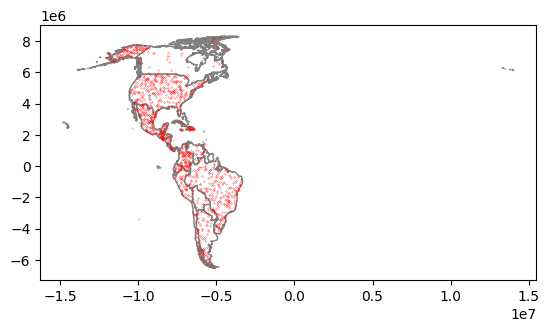

In [ ]:
America=theMapAndData.copy()

justDots=America.copy()
dot_value = 1000000
justDots['num_dots'] = (justDots['mobiles'] / dot_value).astype(int)


justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)


justDots.reset_index(drop=True, inplace=True)
America_dots=gpd.GeoDataFrame(geometry=justDots)


America_8857=America.to_crs(8857)
America_dots_8857=America_dots.to_crs(8857)


base=America_8857.plot(facecolor="white",
                       edgecolor='grey')
America_dots_8857.plot(markersize=0.05,
                       color='red',
                       ax=base)



 The PSM (Proportional Symbol Map)

<Axes: >

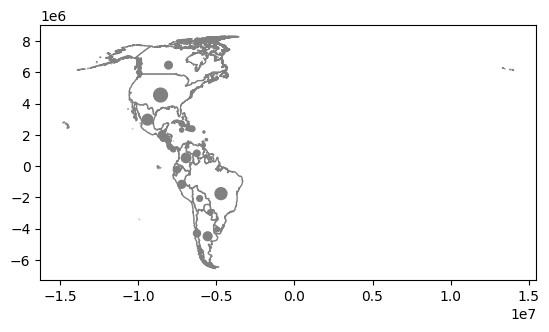

In [ ]:
America_8857=theMapAndData.to_crs(8857)

America_8857_centroids=America_8857.copy()
America_8857_centroids['geometry']=America_8857.representative_point()

America_8857_centroids['size']=America_8857_centroids['mobiles'].apply(lambda x: x**0.5/200)

base=America_8857.plot(facecolor="white",
                       edgecolor='grey')

America_8857_centroids.plot(
    ax=base,
    markersize=America_8857_centroids['size'],
    color='grey'
)

Choropleths

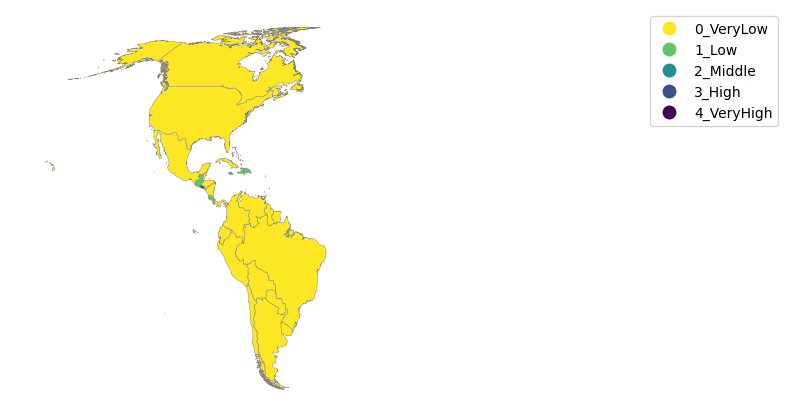

In [ ]:
America_8857=theMapAndData.to_crs(8857)

America_8857['mobiles_density'] = America_8857['mobiles'] / America_8857['sq_km']

import mapclassify
import numpy as np


np.random.seed(12345)

K=5
theVar=America_8857['mobiles_density']

ei5 = mapclassify.EqualInterval(theVar, k=K)
msd = mapclassify.StdMean(theVar)
q5 = mapclassify.Quantiles(theVar, k=K)
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
ht = mapclassify.HeadTailBreaks(theVar)
fj5 = mapclassify.FisherJenks(theVar, k=K)
jc5 = mapclassify.JenksCaspall(theVar, k=K)
mp5 = mapclassify.MaxP(theVar, k=K)

class5 = ei5, msd, q5, mb5, ht, fj5, jc5, mp5

fits = np.array([c.adcm for c in class5])

adcms = pd.DataFrame(fits)

adcms['classifier'] = [c.name for c in class5]

adcms.columns = ['ADCM', 'Classifier']


America_8857['mobiles_density_FJ5'] = fj5.yb


newLabelsForLevels={0:"0_VeryLow", 1:"1_Low", 2:"2_Middle", 3:"3_High", 4:"4_VeryHigh"}
America_8857['mobiles_density_FJ5_cat'] = America_8857['mobiles_density_FJ5'].replace(newLabelsForLevels)




import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))

America_8857.plot(
    column='mobiles_density_FJ5_cat',
    cmap='viridis_r',
    categorical=True,
    edgecolor='grey',
    linewidth=0.3,
    legend=True,
    ax=ax
)

ax.set_axis_off()